# Visual test companion to `pytest` suite

This notebook is a visual companion to the automated tests in `python_version/tests/` (`test_state.py`, `test_gillespie.py`, `test_smc_abc.py`). Those tests assert pass/fail programmatically; this notebook plots the same scenarios so you can eyeball behavior directly.

It covers the two Critical bugs fixed in `documentation/database_structure_review.md`:
1. The reproducible `fast_hop()` crash (fixed in `prc1.py`'s `Prc1.__lt__`) — run across many seeds and plotted.
2. The `smc-abc.py` / `run_gillespie_prc1_on_grid` parameter-signature mismatch (fixed in `simulate_one`) — full SMC-ABC pipeline run on synthetic data, with prior-vs-posterior plots.

Run all cells top to bottom. If any cell raises, that's a regression — the pytest suite (`pytest` from the repo root) covers the same ground and is what should run in CI.

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PYTHON_VERSION_DIR = Path.cwd().parent if Path.cwd().name == "tests" else Path.cwd()
if str(PYTHON_VERSION_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_VERSION_DIR))

from run_gillespie import run_gillespie_prc1, run_gillespie_prc1_on_grid

def _load_smc_abc():
    spec = importlib.util.spec_from_file_location("smc_abc", PYTHON_VERSION_DIR / "smc-abc.py")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

smc_abc = _load_smc_abc()
print("Loaded python_version modules from:", PYTHON_VERSION_DIR)

Loaded python_version modules from: /Users/tiffany/Documents/Research/Fall26-Kramer/prc-recruitment-bayesian-analysis-1/python_version


## 1. `fast_hop()` regression: many seeds, overlaid trajectories

This is the exact call that produced the saved `RuntimeError` traceback in the old `python_version/test.ipynb` (comparing an unattached `Prc1` inside `SortedSet.add`). Before the fix in `prc1.py`'s `Prc1.__lt__`, this cell would eventually raise partway through the loop. After the fix, every seed should complete and plot cleanly.

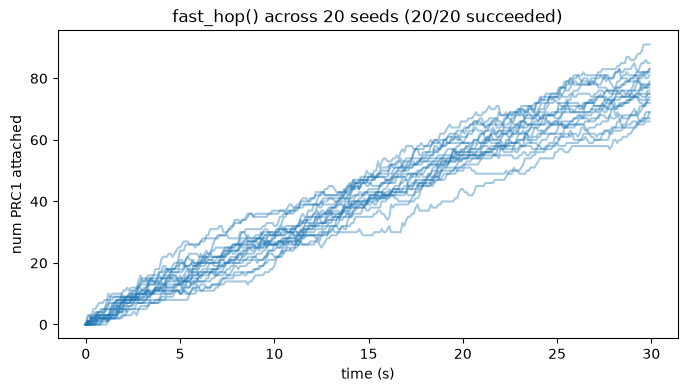

In [2]:
times_obs = np.arange(0, 30, 0.1)
n_seeds = 20

fig, ax = plt.subplots(figsize=(8, 4))
failures = 0
for seed in range(n_seeds):
    np.random.seed(seed)
    try:
        y = run_gillespie_prc1_on_grid(
            4e-5, 1, 10, 0.1, times_obs,
            cooperativity_energy=10, enable_cooperativity=True,
            enable_hopping="fast", max_steps=2000,
        )
        ax.plot(times_obs, y, alpha=0.4, color="C0")
    except Exception as e:
        failures += 1
        print(f"seed {seed} FAILED: {e}")

ax.set_xlabel("time (s)")
ax.set_ylabel("num PRC1 attached")
ax.set_title(f"fast_hop() across {n_seeds} seeds ({n_seeds - failures}/{n_seeds} succeeded)")
plt.show()

assert failures == 0, f"{failures}/{n_seeds} seeds crashed -- fast_hop regression reintroduced"

## 2. Hopping-mode comparison (`False` / `"slow"` / `"fast"`)

Sanity check that all three hopping modes still run and produce trajectories in a comparable range.

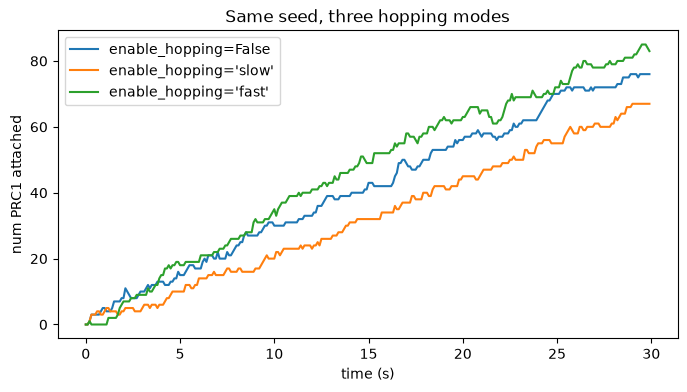

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for mode, color in zip([False, "slow", "fast"], ["C0", "C1", "C2"]):
    np.random.seed(0)
    y = run_gillespie_prc1_on_grid(
        4e-5, 1, 10, 0.1, times_obs,
        enable_hopping=mode, max_steps=2000,
    )
    ax.plot(times_obs, y, label=f"enable_hopping={mode!r}", color=color)

ax.set_xlabel("time (s)")
ax.set_ylabel("num PRC1 attached")
ax.legend()
ax.set_title("Same seed, three hopping modes")
plt.show()

## 3. SMC-ABC posterior recovery (fixed 4-parameter signature)

Generates synthetic "observed" data from a known `theta_true`, then runs `smc_abc_prc1` and checks the posterior concentrates near the true value for each of the 4 rate parameters: `initial_binding_rate`, `singly_bound_detachment_rate`, `base_double_attachment_rate`, `base_double_detachment_rate`.

Before the fix, `smc_abc.simulate_one` called `run_gillespie_prc1_on_grid` with a stale 3-parameter signature (`k0` instead of the two double-attachment/detachment rates) and raised `TypeError` immediately -- this cell could not run at all.

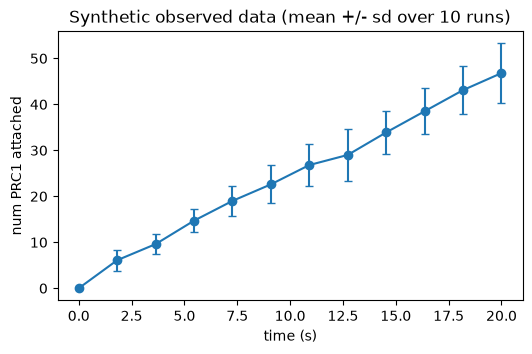

In [4]:
theta_true = np.array([4e-5, 1.0, 10.0, 0.1])
param_names = [
    "initial_binding_rate",
    "singly_bound_detachment_rate",
    "base_double_attachment_rate",
    "base_double_detachment_rate",
]
times_obs_smc = np.linspace(0.0, 20.0, 12)

y_obs = np.array([
    smc_abc.simulate_one(theta_true, times_obs_smc, seed=s)
    for s in range(10)
])

plt.figure(figsize=(6, 3.5))
plt.errorbar(times_obs_smc, y_obs.mean(axis=0), yerr=y_obs.std(axis=0), fmt="o-", capsize=3)
plt.xlabel("time (s)")
plt.ylabel("num PRC1 attached")
plt.title("Synthetic observed data (mean +/- sd over 10 runs)")
plt.show()

In [5]:
phi_mu = np.log(theta_true)
phi_sd = np.full(4, 0.4)

result = smc_abc.smc_abc_prc1(
    times_obs=times_obs_smc,
    y_obs=y_obs,
    phi_mu=phi_mu,
    phi_sd=phi_sd,
    P=15,
    G=2,
    pool=80,
    n_reps=2,
    eps_quantile=70.0,
    cov_scale=1.5,
    seed=7,
    n_jobs=-1,
    batch_factor=2,
)

theta_particles = np.exp(result.particles_phi)
w = result.weights
posterior_mean = (theta_particles * w[:, None]).sum(axis=0)

print("eps history:", result.eps_history)
print("true theta:     ", theta_true)
print("posterior mean: ", posterior_mean)

eps history: [57.17815995035728, 54.84214277315801]
true theta:      [4.e-05 1.e+00 1.e+01 1.e-01]
posterior mean:  [3.71116478e-05 1.21279269e+00 9.05953674e+00 1.03700987e-01]


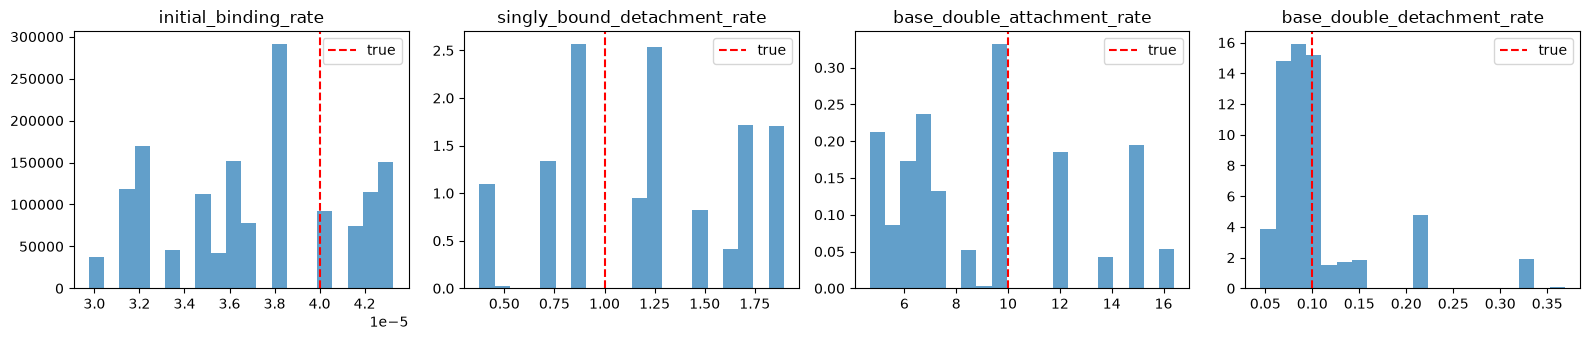

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for j, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(theta_particles[:, j], bins=20, weights=w, density=True, alpha=0.7)
    ax.axvline(theta_true[j], color="red", linestyle="--", label="true")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()